# Notebook 4e — RF con CV por animal: Score lesional (regresión) — **SOLO granja VC30D**
### Tuberculosis bovina

Target: **Score_lesional** — variable ordinal (0, 1, 2, 4, 5) tratada como continua.
Análisis restringido a la **explotación VC30D**.

> **Pregunta de investigación:** ¿pueden los biomarcadores predecir la gravedad lesional
> *dentro de la explotación VC30D*, sin confusor inter-granja?

**Comparar con:**
- *Notebook 2e*: cohorte completo sin Expl.
- *Notebook 3e*: cohorte completo con Expl.
- *Este notebook (4e)*: análisis intra-granja VC30D.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import RepeatedKFold, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from scipy.stats import spearmanr
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

GRANJA = "VC30D"

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Score_lesional")
d = d[d[tb.GROUP_COL] == GRANJA].copy().reset_index(drop=True)
d = tb.drop_sparse_rows(d)

X_all = d[tb.MODEL_FEATURES].copy()
y     = d["Score_lesional"].astype(float).values

print(f"Explotación: {GRANJA}")
print(f"Dataset: n={len(y)}")
print(f"Features ({len(tb.MODEL_FEATURES)}): {tb.MODEL_FEATURES}")
print(f"Score_lesional — Media: {y.mean():.2f}, SD: {y.std():.2f}")
print(f"Distribución:", pd.Series(y).value_counts().sort_index().to_dict())
print(f"\nNota: análisis intra-granja {GRANJA}. Sin confusor inter-granja.")

Explotación: VC30D
Dataset: n=55
Features (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Score_lesional — Media: 1.49, SD: 1.75
Distribución: {0.0: 23, 1.0: 13, 2.0: 6, 4.0: 8, 5.0: 5}

Nota: análisis intra-granja VC30D. Sin confusor inter-granja.


## 2. Random Forest Regressor y estrategia de validación

**CV por animal en VC30D (RepeatedKFold, 5×10):**
- Métrica primaria: Spearman r (robustez ante outliers, apropiada para ordinales).
- Métricas secundarias: R², RMSE.
- `min_samples_leaf=3` para adaptarse al n reducido de la granja.

In [2]:
def make_rf_reg(n_estimators=100, min_samples_leaf=3):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_4e(feature_list, n_estimators=100):
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("reg", make_rf_reg(n_estimators=n_estimators))])

CV_OUTER = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_metrics_4e(feature_list, X, y, cv=None, detailed=False, n_estimators=100):
    if cv is None:
        cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_4e(feature_list, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(te) < 3: continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        pred = pf.predict(Xs.iloc[te])
        spr  = float(spearmanr(y[te], pred).correlation)
        r2   = float(r2_score(y[te], pred))
        rmse = float(np.sqrt(mean_squared_error(y[te], pred)))
        rows.append(dict(spearman=spr, r2=r2, rmse=rmse))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.spearman.mean(), df_r.spearman.std()

print(f"Evaluación baseline RF ({GRANJA}):")
base_m, base_s = cv_metrics_4e(tb.MODEL_FEATURES, X_all, y)
print(f"  Spearman r = {base_m:.3f} ± {base_s:.3f}")

Evaluación baseline RF (VC30D):
  Spearman r = 0.301 ± 0.290


## 3. Pipeline de selección de características

Paso 1: Ajustando RF completo en VC30D...
OOB R²: 0.136

Ranking importancia de permutación (VC30D):
                 pretty  imp_mean  imp_std
     Anaplasma spp. (+)    0.3132   0.0731
log(1+Carga piroplasma)    0.1756   0.0447
                 Calcio    0.1299   0.0241
             Vitamina D    0.1165   0.0290
            Edad (años)    0.0854   0.0197
                   Raza    0.0280   0.0092
     Theileria spp. (+)    0.0195   0.0082
         Piroplasma (+)    0.0000   0.0000


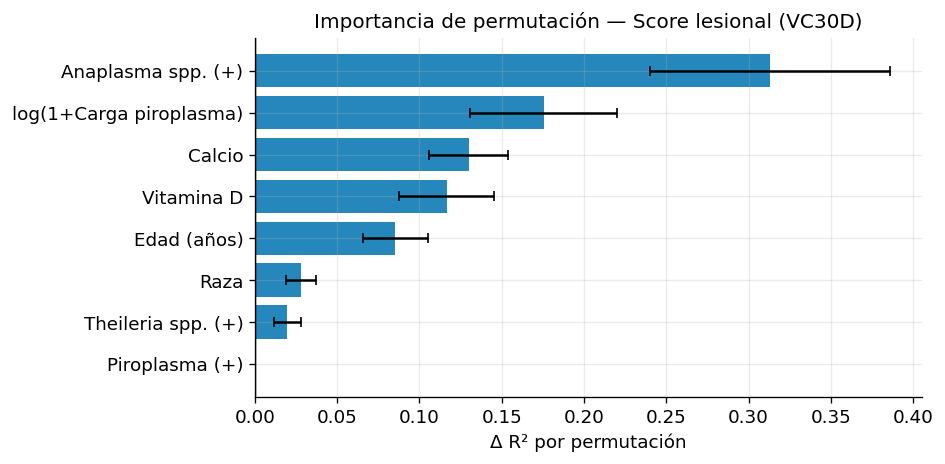

In [3]:
print(f"Paso 1: Ajustando RF completo en {GRANJA}...")
full_pipe = make_pipe_4e(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB R²: {full_pipe.named_steps['reg'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="r2",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  tb.MODEL_FEATURES,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print(f"\nRanking importancia de permutación ({GRANJA}):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
order = imp_df.sort_values("imp_mean")
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación")
ax.set_title(f"Importancia de permutación — Score lesional ({GRANJA})")
plt.tight_layout(); plt.savefig("figures/fig_04e_perm_importance_full.png"); plt.show()

Orden de eliminación: ['PIROPLASMA', 'THEILERIA', 'RAZA2', 'EDAD', 'VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'ANAPLASMA']

   8 features [baseline] Spearman=0.232±0.263
   7 features [-PIROPLASMA          ] Spearman=0.287±0.301  Δ=+0.055
   6 features [-THEILERIA           ] Spearman=0.213±0.242  Δ=-0.019
   5 features [-RAZA2               ] Spearman=0.331±0.305  Δ=+0.099
   4 features [-EDAD                ] Spearman=0.313±0.314  Δ=+0.081
   3 features [-VITAMINA_D          ] Spearman=0.415±0.254  Δ=+0.183
   2 features [-CALCIO              ] Spearman=0.535±0.214  Δ=+0.303
   1 features [-PIROPLASMA_Q_log    ] Spearman=0.372±0.323  Δ=+0.140


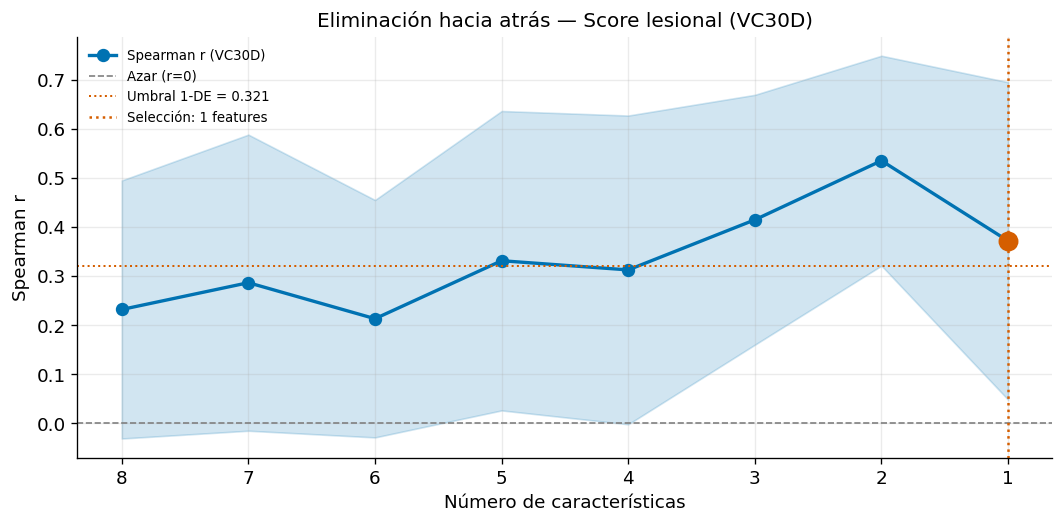


Features SELECCIONADOS (1): ['ANAPLASMA']


In [4]:
CV_SEL = RepeatedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)
elim_order = imp_df.sort_values("imp_mean", ascending=True)["feature"].tolist()
print(f"Orden de eliminación: {elim_order}\n")

current_features = tb.MODEL_FEATURES.copy()
history = []

m0, s0 = cv_metrics_4e(current_features, X_all, y, cv=CV_SEL)
history.append({"n": len(current_features), "features": current_features.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_features):2d} features [baseline] Spearman={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_features or len(current_features) <= 1: break
    test_feats = [f for f in current_features if f != feat]
    m, s = cv_metrics_4e(test_feats, X_all, y, cv=CV_SEL)
    history.append({"n": len(test_feats), "features": test_feats.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_feats):2d} features [-{feat:20s}] Spearman={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_features = test_feats

hist_df = pd.DataFrame(history)

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
threshold    = best_mu - hist_df.loc[best_idx, "std"]
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]
SELECTED_4E  = list(parsimonious.features)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label=f"Spearman r ({GRANJA})")
ax.fill_between(hist_df.n, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"], alpha=0.18, color=PALETTE[0])
ax.axhline(0, ls="--", color="grey", lw=1, label="Azar (r=0)")
ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5, label=f"Selección: {int(parsimonious.n)} features")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)
ax.set_xlabel("Número de características"); ax.set_ylabel("Spearman r")
ax.set_title(f"Eliminación hacia atrás — Score lesional ({GRANJA})")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_04e_feature_selection_curve.png"); plt.show()
print(f"\nFeatures SELECCIONADOS ({len(SELECTED_4E)}): {SELECTED_4E}")

## 4. Evaluación del modelo final (CV por animal, 5×10)

Features seleccionados (4): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'ANAPLASMA']

Métricas CV por animal (5×10, VC30D):
  Spearman r = 0.366 ± 0.311
  R²         = -0.015 ± 0.577
  RMSE       = 1.553 ± 0.314


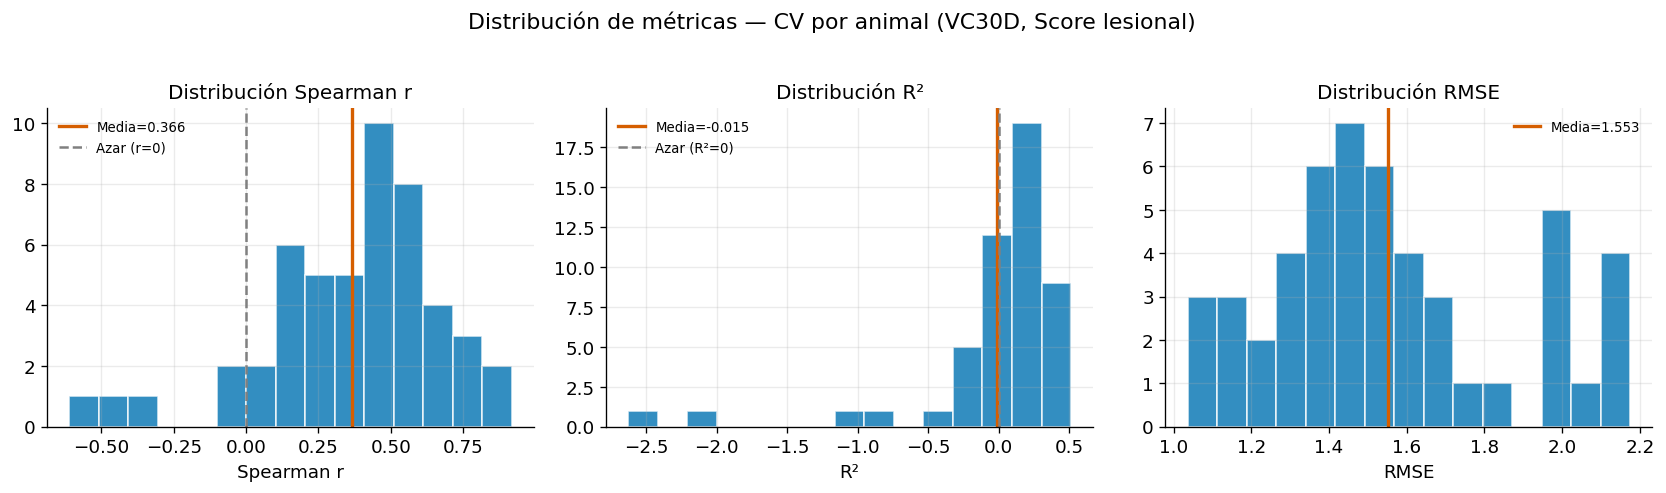

In [5]:
SELECTED_4E = ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log','ANAPLASMA']
Xs = X_all[SELECTED_4E].copy()
print(f"Features seleccionados ({len(SELECTED_4E)}): {SELECTED_4E}\n")

detailed_df = cv_metrics_4e(SELECTED_4E, X_all, y, cv=CV_OUTER, detailed=True, n_estimators=700)
m = detailed_df.mean(); s = detailed_df.std()

print(f"Métricas CV por animal (5×10, {GRANJA}):")
print(f"  Spearman r = {m.spearman:.3f} ± {s.spearman:.3f}")
print(f"  R²         = {m.r2:.3f} ± {s.r2:.3f}")
print(f"  RMSE       = {m.rmse:.3f} ± {s.rmse:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title, chance_val, chance_lbl in zip(
    axes,
    ["spearman", "r2", "rmse"],
    ["Spearman r", "R²", "RMSE"],
    [0, 0, None],
    ["Azar (r=0)", "Azar (R²=0)", None]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    if chance_val is not None:
        ax.axvline(chance_val, color="grey", ls="--", lw=1.5, label=chance_lbl)
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle(f"Distribución de métricas — CV por animal ({GRANJA}, Score lesional)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_04e_metrics_dist.png", bbox_inches="tight"); plt.show()

## 5. Interpretabilidad global — SHAP

OOB R²: 0.224
Features: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'ANAPLASMA']


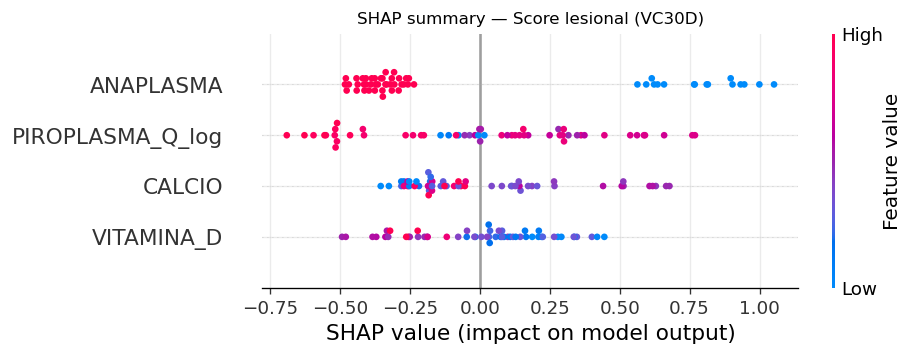

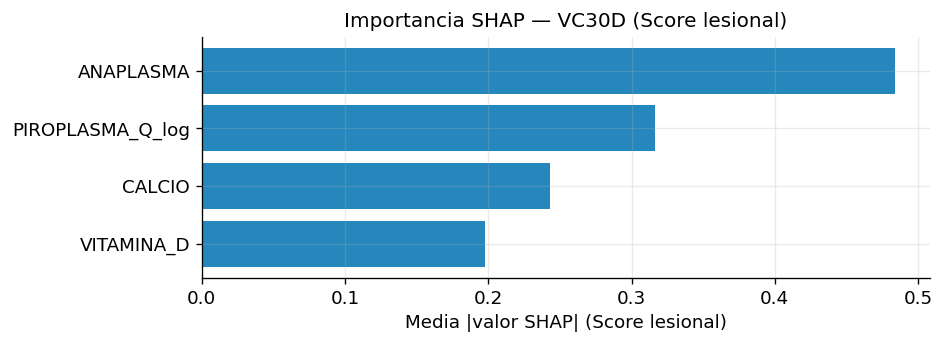

In [6]:
FINAL_4E = make_pipe_4e(SELECTED_4E, n_estimators=500).fit(Xs, y)
print(f"OOB R²: {FINAL_4E.named_steps['reg'].oob_score_:.3f}")

prep_4e  = FINAL_4E.named_steps["prep"]
reg_4e   = FINAL_4E.named_steps["reg"]
Xt_4e    = prep_4e.transform(Xs)
names_4e = list(prep_4e.get_feature_names_out())

explainer_4e = shap.TreeExplainer(reg_4e)
shap_vals_4e = explainer_4e.shap_values(Xt_4e)

if isinstance(shap_vals_4e, list):
    sv_e = shap_vals_4e[0]
elif np.asarray(shap_vals_4e).ndim == 3:
    sv_e = np.asarray(shap_vals_4e)[:, :, 0]
else:
    sv_e = np.asarray(shap_vals_4e)

exp_val_4e = (float(explainer_4e.expected_value[0])
              if isinstance(explainer_4e.expected_value, (list, np.ndarray))
              else float(explainer_4e.expected_value))

print(f"Features: {names_4e}")

plt.figure(figsize=(9, max(4, 0.5 * len(names_4e))))
shap.summary_plot(sv_e, Xt_4e, feature_names=names_4e, show=False, max_display=len(names_4e))
plt.title(f"SHAP summary — Score lesional ({GRANJA})", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_04e_shap_summary.png", bbox_inches="tight"); plt.show()

si_4e = pd.DataFrame({"feature": names_4e, "mean_abs": np.abs(sv_e).mean(0)}).sort_values("mean_abs")
fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(names_4e))))
ax.barh(si_4e.feature, si_4e.mean_abs, color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Media |valor SHAP| (Score lesional)")
ax.set_title(f"Importancia SHAP — {GRANJA} (Score lesional)")
plt.tight_layout(); plt.savefig("figures/fig_04e_shap_importance.png"); plt.show()

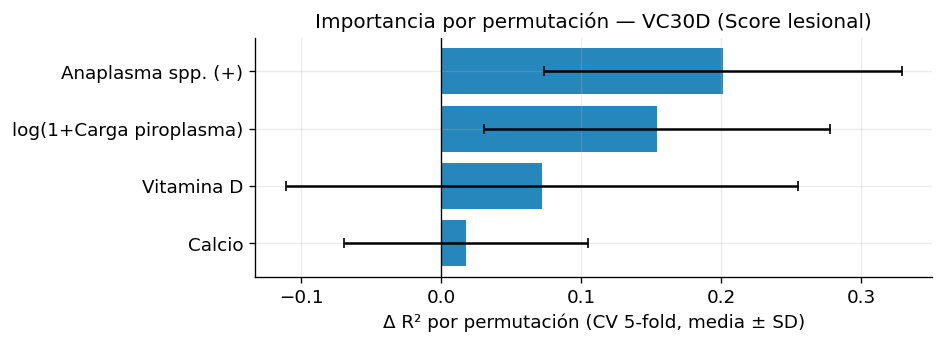

In [7]:
imp_runs_4e = []
cv_stab = KFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs):
    if len(te) < 3: continue
    pf = clone(make_pipe_4e(SELECTED_4E)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="r2", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_4e.append(pd.Series(pi_f.importances_mean, index=SELECTED_4E))

imp_mat_4e = pd.concat(imp_runs_4e, axis=1)
imp_ord_4e = imp_mat_4e.mean(axis=1).sort_values().index

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(SELECTED_4E))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_4e],
        imp_mat_4e.mean(axis=1)[imp_ord_4e],
        xerr=imp_mat_4e.std(axis=1)[imp_ord_4e],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación (CV 5-fold, media ± SD)")
ax.set_title(f"Importancia por permutación — {GRANJA} (Score lesional)")
plt.tight_layout(); plt.savefig("figures/fig_04e_perm_importance_cv.png"); plt.show()

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


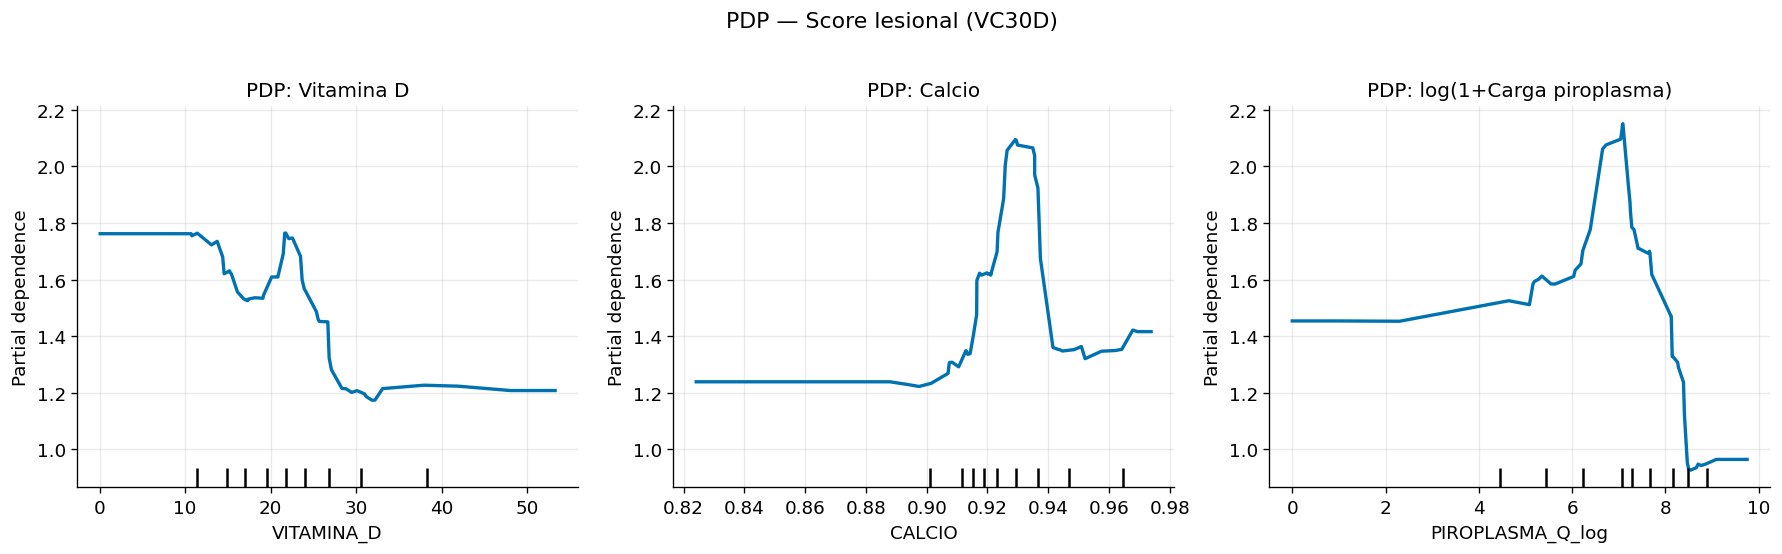

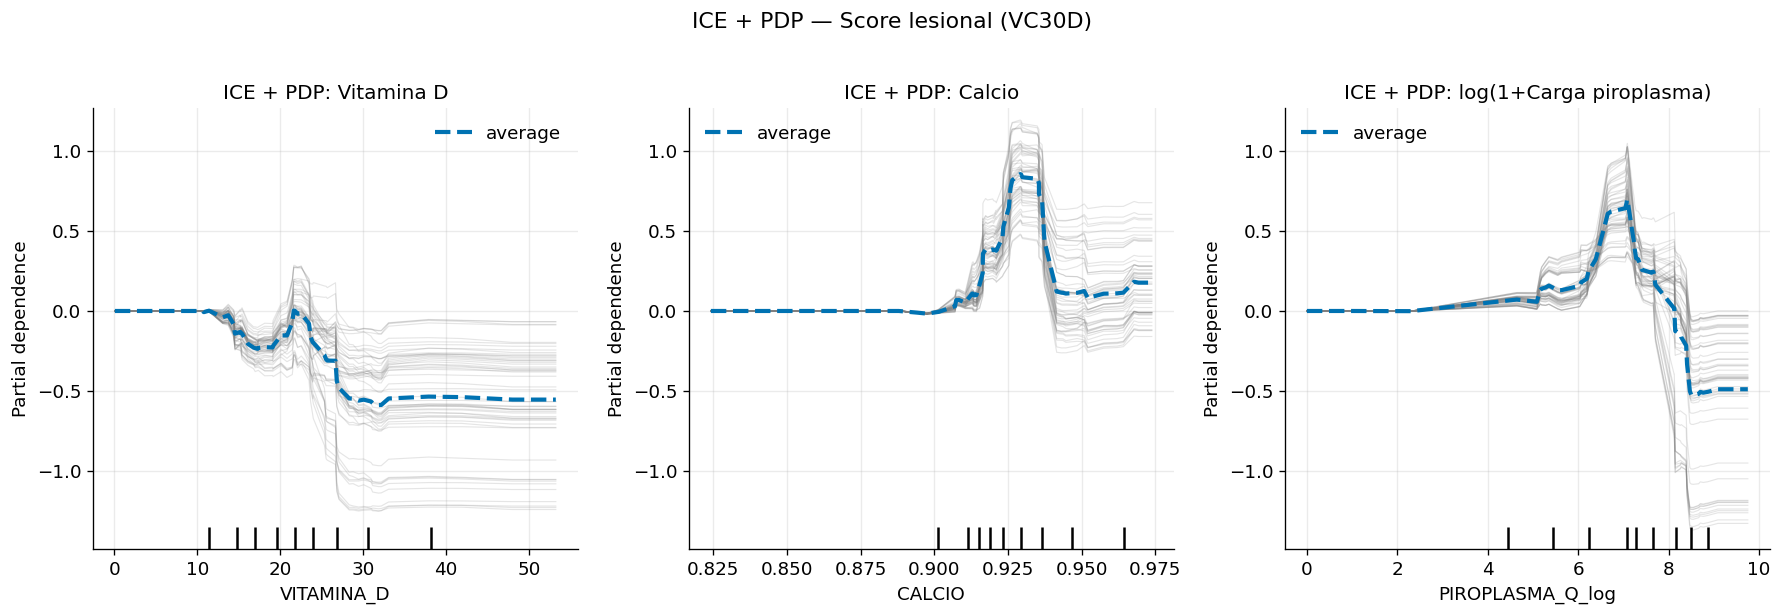

In [8]:
CONT_4E = [f for f in SELECTED_4E if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_4E:
    CONT_4E = [f for f in SELECTED_4E if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_4E}")
if CONT_4E:
    n_c = len(CONT_4E)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_4E, Xs, CONT_4E, kind="average",
        ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_4E):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle(f"PDP — Score lesional ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04e_pdp.png", bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_4E, Xs, CONT_4E, kind="both",
        ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_4E):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle(f"ICE + PDP — Score lesional ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04e_ice.png", bbox_inches="tight"); plt.show()

## 7. ALE + Waterfall + Contrafactuales

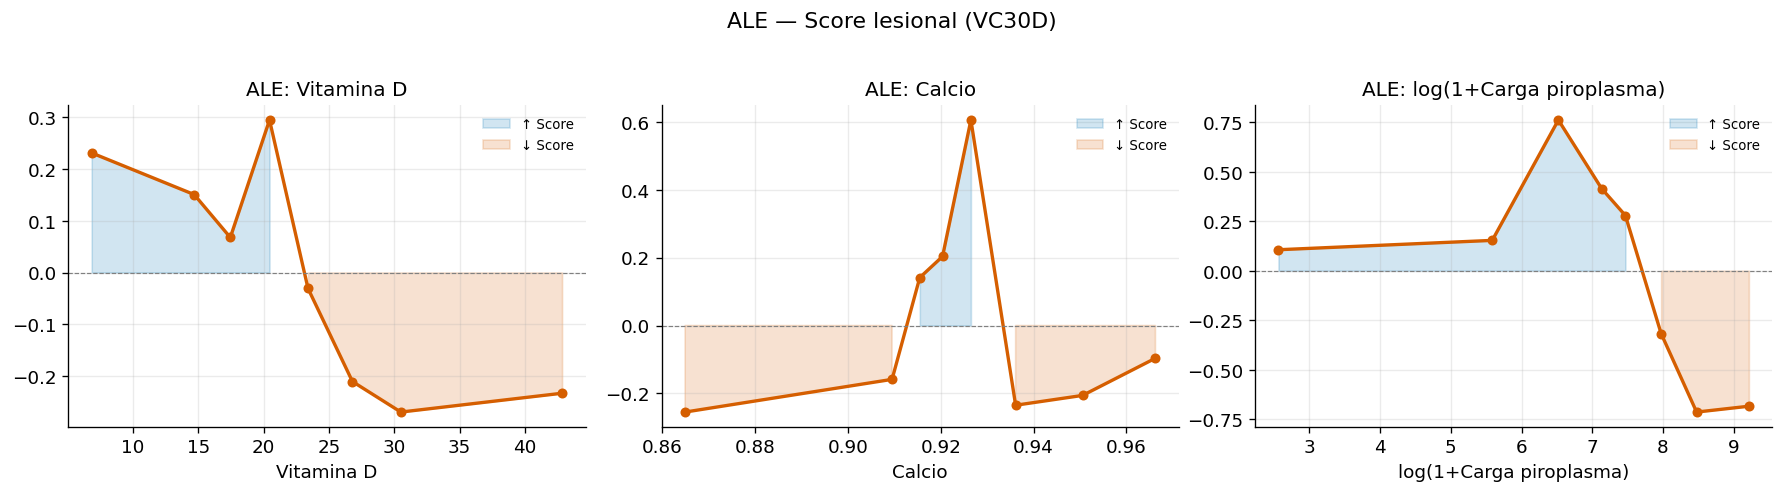

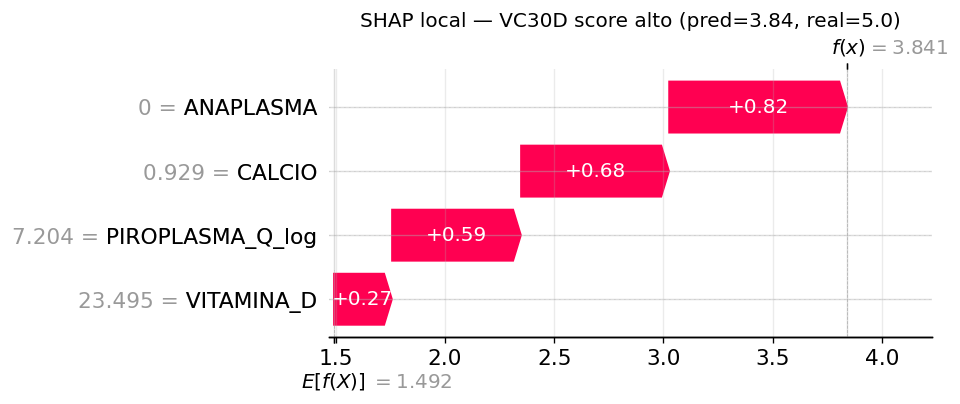

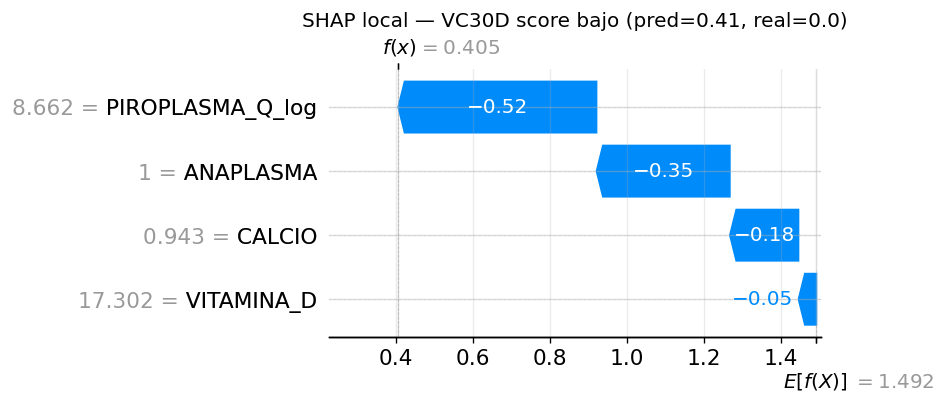

In [9]:
def ale_1d_reg(model, X, feat, bins=8):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict(hi) - model.predict(lo)).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_4E:
    n_c = len(CONT_4E)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_4E):
        cx, ale = ale_1d_reg(FINAL_4E, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ Score")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ Score")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle(f"ALE — Score lesional ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04e_ale.png", bbox_inches="tight"); plt.show()

# SHAP waterfall
y_pred_4e = FINAL_4E.predict(Xs)
idx_high = int(np.argmax(y_pred_4e)); idx_low = int(np.argmin(y_pred_4e))
shap_exp_4e = shap.Explanation(values=sv_e, base_values=exp_val_4e, data=Xt_4e, feature_names=names_4e)

for tag, idx in [("score_alto", idx_high), ("score_bajo", idx_low)]:
    fig, _ = plt.subplots(figsize=(9, 4))
    shap.plots.waterfall(shap_exp_4e[idx], max_display=len(names_4e), show=False)
    plt.title(f"SHAP local — {GRANJA} {tag.replace('_',' ')} (pred={y_pred_4e[idx]:.2f}, real={y[idx]:.1f})")
    plt.tight_layout()
    plt.savefig(f"figures/fig_04e_waterfall_{tag}.png", bbox_inches="tight"); plt.show()

In [10]:
print(f"Análisis contrafactual — Score lesional ({GRANJA})")
threshold_cf = y.mean()
print(f"Umbral: media del score = {threshold_cf:.2f}\n")

above = np.where(y_pred_4e > threshold_cf)[0]
below = np.where(y_pred_4e <= threshold_cf)[0]

print(f"Animales con score pred > {threshold_cf:.2f}: n={len(above)}")
print(f"Animales con score pred <= {threshold_cf:.2f}: n={len(below)}")

if CONT_4E and len(above) >= 3 and len(below) >= 3:
    Xs_above = Xs.iloc[above].copy()
    Xs_below = Xs.iloc[below].copy()
    print("\nMedianas por grupo:")
    for f in CONT_4E:
        med_a = Xs_above[f].median(); med_b = Xs_below[f].median()
        print(f"  {tb.PRETTY.get(f, f):25s}  score_alto: {med_a:.3f}  score_bajo: {med_b:.3f}")

    if len(above) > 0:
        target_idx = above[0]
        Xi = Xs.iloc[[target_idx]].copy()
        pred_i = FINAL_4E.predict(Xi)[0]
        print(f"\nAnimal idx={target_idx}, pred={pred_i:.2f} → objetivo: reducir al umbral ({threshold_cf:.2f})")
        results = []
        for f in CONT_4E:
            for step in [0.05, 0.1, 0.2, 0.3, 0.5]:
                Xc = Xi.copy()
                Xc[f] = Xc[f].iloc[0] * (1 - step)
                pnew = FINAL_4E.predict(Xc)[0]
                results.append({"feature": f, "factor": step, "pred": pnew, "delta": pnew - pred_i})
        cf_df = pd.DataFrame(results)
        ok_cf = cf_df[cf_df.pred <= threshold_cf].copy()
        if not ok_cf.empty:
            print("\n¿Qué cambios reducen el score por debajo del umbral?")
            print(ok_cf.groupby("feature").first()[["factor", "pred", "delta"]].round(3).to_string())
        else:
            print("Ningún cambio proporcional simple redujo al umbral.")

Análisis contrafactual — Score lesional (VC30D)
Umbral: media del score = 1.49

Animales con score pred > 1.49: n=23
Animales con score pred <= 1.49: n=32

Medianas por grupo:
  Vitamina D                 score_alto: 21.655  score_bajo: 23.817
  Calcio                     score_alto: 0.923  score_bajo: 0.922
  log(1+Carga piroplasma)    score_alto: 7.082  score_bajo: 7.535

Animal idx=0, pred=2.15 → objetivo: reducir al umbral (1.49)

¿Qué cambios reducen el score por debajo del umbral?
         factor   pred  delta
feature                      
CALCIO     0.05  1.244 -0.904


## 8. Síntesis

### Tabla comparativa

| Métrica | Nb 2e — completo sin expl | Nb 3e — completo + Expl | **Nb 4e — VC30D intra-granja** |
|---|---|---|---|
| Spearman r | — | — | **—** |
| R² | — | — | **—** |
| RMSE | — | — | **—** |
| n animales | ~103 | ~103 | **solo VC30D** |

**Nota interpretativa:** La reducción de n al subseleccionar VC30D aumenta la varianza
del estimador CV. Si Spearman r y R² se mantienen respecto a 2e/3e, sugiere que
la señal es genuinamente intra-granja.